In [1]:
import scarf

scarf.set_verbosity('WARNING')

In [2]:
scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='./scarf_datasets',
    zarr=True,
)

PosixPath('/tmp/tmp3al7cp9g/scarf_datasets/bastidas-ponce_4K_pancreas-d15_rnaseq')

In [3]:
ds = scarf.DataStore(
    f"scarf_datasets/bastidas-ponce_4K_pancreas-d15_rnaseq/data.zarr",
    nthreads=4, 
    default_assay='RNA'
)

In [4]:
ds

DataStore has 3413 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_G2M_score', 
            'G2M_score', 'clusters_coarse', 'RNA_nFeatures', 'RNA_percentRibo', 'RNA_cell_cycle_phase', 
            'RNA_nCounts', 'RNA_S_score', 'RNA_UMAP2', 'RNA_cluster', 'clusters', 
            'RNA_UMAP1', 'S_score'
   RNA assay has 12497 (27998) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'highly_variable_genes', 
            'I__hvgs', 'dropOuts'

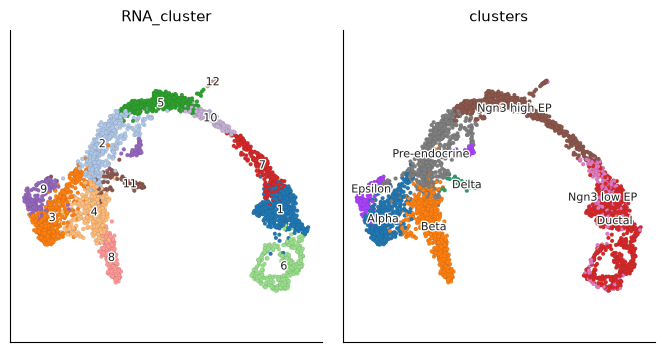

PlotResult(axes=2, tables=0, legends=2, scales=3, owns_figure=True, rendered=True)

In [5]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['RNA_cluster', 'clusters'],
    legend_loc='on_data',
)

In [6]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key="RNA_cluster",    # Column that contains cluster information 
    sources=[1],                      # Source clusters
    sinks=[3],                        # Sink clusters
)

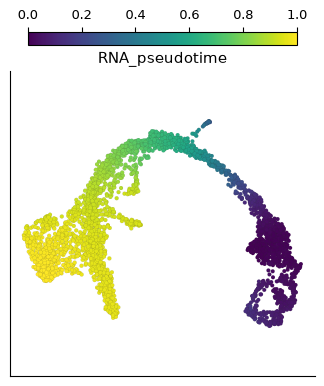

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
)

In [8]:
markers = ds.run_pseudotime_marker_search(
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
)

In [9]:
markers.table.head()

,feature_index,feature_name,r_value,p_value
0,6,Mrpl15,-0.077717,5.480191e-06
1,14,Vcpip1,0.019690,2.501445e-01
2,15,Snhg6,-0.244398,1.340596e-47
3,16,Tcf24,-0.003545,8.360026e-01
4,17,Ppp1r42,-0.033779,4.847145e-02


In [10]:
corr_genes_df = markers.table

In [11]:
corr_genes_df.sort_values('r_value')[:15]

,feature_index,feature_name,r_value,p_value
8853,18864,Spp1,-0.853747,0.0
10280,22385,Rps19,-0.811618,0.0
11328,24581,Rpl13,-0.808717,0.0
172,431,Dbi,-0.801796,0.0
7640,16254,Rps8,-0.787065,0.0
9305,19815,Rpl32,-0.777364,0.0
1409,3163,Sparc,-0.775107,0.0
12187,26498,Rps4x,-0.768438,0.0
9683,20787,Mgst1,-0.762069,0.0
6445,13425,Rpl12,-0.754217,0.0


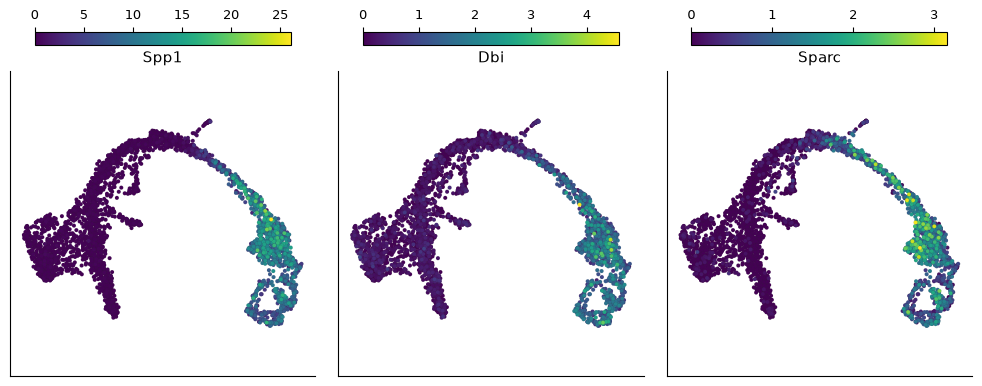

PlotResult(axes=3, tables=0, legends=3, scales=1, owns_figure=True, rendered=True)

In [12]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['Spp1', 'Dbi', 'Sparc'],
    sort_values=True,
)

In [13]:
corr_genes_df.sort_values('r_value', ascending=False)[:10]

,feature_index,feature_name,r_value,p_value
9838,21244,Aplp1,0.717088,0.000000e+00
6809,14296,Gnas,0.708386,0.000000e+00
10760,23549,Cpe,0.703213,0.000000e+00
1415,3186,Fam183b,0.642701,0.000000e+00
11580,25060,Hmgn3,0.614297,0.000000e+00
12219,26573,Bex2,0.608843,0.000000e+00
3859,8171,Tuba1a,0.594564,0.000000e+00
12290,26730,Pcsk1n,0.593595,0.000000e+00
1968,4284,Ubb,0.578068,1.342277e-303
942,2189,Rap1b,0.568015,6.955851e-291


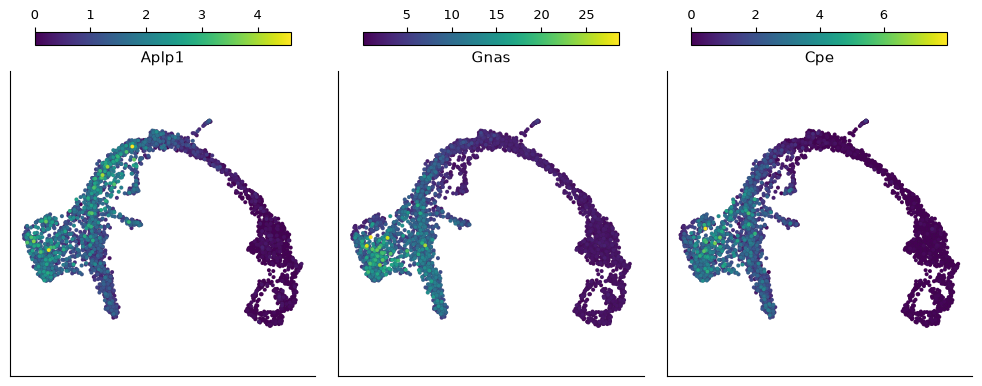

PlotResult(axes=3, tables=0, legends=3, scales=1, owns_figure=True, rendered=True)

In [14]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['Aplp1', 'Gnas', 'Cpe'],
    sort_values=True,
)